# TerraAlert — Wildfire Dataset EDA
**Dataset 1:** NASA FIRMS (Fire Information for Resource Management System)  
**Dataset 2:** 1.88 Million US Wildfires (Kaggle)  
**Research Question:** Do gradient boosting methods (XGBoost/LightGBM) outperform Random Forest for tabular wildfire risk prediction?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load 1.88M wildfire dataset
print('Loading wildfire dataset...')
df = pd.read_csv('../data/wildfires/us_wildfires.csv', low_memory=False)

print(f'Shape: {df.shape}')
print(f'Years: {df["FIRE_YEAR"].min()} - {df["FIRE_YEAR"].max()}')
print(f'Columns: {list(df.columns)}')
df.head()

Loading wildfire dataset...
Shape: (1880465, 39)
Years: 1992 - 2015
Columns: ['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT', 'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID', 'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME', 'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'Shape']


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,1,1,FS-1418826,FED,FS-FIRESTAT,FS,USCAPNF,Plumas National Forest,0511,Plumas National Forest,...,A,40.036944,-121.005833,5.0,USFS,CA,63,63.0,Plumas,b'\x00\x01\xad\x10\x00\x00\xe8d\xc2\x92_@^\xc0...
1,2,2,FS-1418827,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,A,38.933056,-120.404444,5.0,USFS,CA,61,61.0,Placer,b'\x00\x01\xad\x10\x00\x00T\xb6\xeej\xe2\x19^\...
2,3,3,FS-1418835,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,A,38.984167,-120.735556,13.0,STATE OR PRIVATE,CA,17,17.0,El Dorado,b'\x00\x01\xad\x10\x00\x00\xd0\xa5\xa0W\x13/^\...
3,4,4,FS-1418845,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,A,38.559167,-119.913333,5.0,USFS,CA,3,3.0,Alpine,b'\x00\x01\xad\x10\x00\x00\x94\xac\xa3\rt\xfa]...
4,5,5,FS-1418847,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,...,A,38.559167,-119.933056,5.0,USFS,CA,3,3.0,Alpine,b'\x00\x01\xad\x10\x00\x00@\xe3\xaa.\xb7\xfb]\...


In [3]:
# See all columns and what's useful
print("ALL COLUMNS:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2}. {col}")


ALL COLUMNS:
   1. OBJECTID
   2. FOD_ID
   3. FPA_ID
   4. SOURCE_SYSTEM_TYPE
   5. SOURCE_SYSTEM
   6. NWCG_REPORTING_AGENCY
   7. NWCG_REPORTING_UNIT_ID
   8. NWCG_REPORTING_UNIT_NAME
   9. SOURCE_REPORTING_UNIT
  10. SOURCE_REPORTING_UNIT_NAME
  11. LOCAL_FIRE_REPORT_ID
  12. LOCAL_INCIDENT_ID
  13. FIRE_CODE
  14. FIRE_NAME
  15. ICS_209_INCIDENT_NUMBER
  16. ICS_209_NAME
  17. MTBS_ID
  18. MTBS_FIRE_NAME
  19. COMPLEX_NAME
  20. FIRE_YEAR
  21. DISCOVERY_DATE
  22. DISCOVERY_DOY
  23. DISCOVERY_TIME
  24. STAT_CAUSE_CODE
  25. STAT_CAUSE_DESCR
  26. CONT_DATE
  27. CONT_DOY
  28. CONT_TIME
  29. FIRE_SIZE
  30. FIRE_SIZE_CLASS
  31. LATITUDE
  32. LONGITUDE
  33. OWNER_CODE
  34. OWNER_DESCR
  35. STATE
  36. COUNTY
  37. FIPS_CODE
  38. FIPS_NAME
  39. Shape


In [4]:
# Your prediction target - fire size classes
print("Fire Size Classes:")
print(df['FIRE_SIZE_CLASS'].value_counts())
print("\nWhat each class means:")
print("A = 0-0.25 acres")
print("B = 0.26-9.9 acres") 
print("C = 10-99.9 acres")
print("D = 100-299 acres")
print("E = 300-999 acres")
print("F = 1000-4999 acres")
print("G = 5000+ acres (catastrophic)")

Fire Size Classes:
FIRE_SIZE_CLASS
B    939376
A    666919
C    220077
D     28427
E     14107
F      7786
G      3773
Name: count, dtype: int64

What each class means:
A = 0-0.25 acres
B = 0.26-9.9 acres
C = 10-99.9 acres
D = 100-299 acres
E = 300-999 acres
F = 1000-4999 acres
G = 5000+ acres (catastrophic)


In [5]:
# Which columns actually matter - drop the junk
useful_cols = [
    'FIRE_YEAR', 'DISCOVERY_DOY', 'STAT_CAUSE_DESCR', 
    'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'STATE', 
    'LATITUDE', 'LONGITUDE', 'CONT_DOY'
]

df_clean = df[useful_cols].copy()
print(f'Reduced from 39 → {len(useful_cols)} useful columns')
print(f'Shape: {df_clean.shape}')
df_clean.head()

Reduced from 39 → 9 useful columns
Shape: (1880465, 9)


,FIRE_YEAR,DISCOVERY_DOY,STAT_CAUSE_DESCR,FIRE_SIZE,FIRE_SIZE_CLASS,STATE,LATITUDE,LONGITUDE,CONT_DOY
0,2005,33,Miscellaneous,0.10,A,CA,40.036944,-121.005833,33.0
1,2004,133,Lightning,0.25,A,CA,38.933056,-120.404444,133.0
2,2004,152,Debris Burning,0.10,A,CA,38.984167,-120.735556,152.0
3,2004,180,Lightning,0.10,A,CA,38.559167,-119.913333,185.0
4,2004,180,Lightning,0.10,A,CA,38.559167,-119.933056,185.0


In [6]:
# Top 10 states by wildfire count
state_counts = df['STATE'].value_counts().head(10)
print("Top 10 States by Wildfire Count:")
print(state_counts)

print(f"\nCalifornia wildfires: {len(df[df['STATE']=='CA']):,}")
print(f"% of total: {len(df[df['STATE']=='CA'])/len(df)*100:.1f}%")

# California vs Class B specifically
ca_fires = df[df['STATE'] == 'CA']
print(f"\nCalifornia Class breakdown:")
print(ca_fires['FIRE_SIZE_CLASS'].value_counts())

Top 10 States by Wildfire Count:
STATE
CA    189550
GA    168867
TX    142021
NC    111277
FL     90261
SC     81315
NY     80870
MS     79230
AZ     71586
AL     66570
Name: count, dtype: int64

California wildfires: 189,550
% of total: 10.1%

California Class breakdown:
FIRE_SIZE_CLASS
A    98309
B    76942
C     9825
D     2137
E     1187
F      756
G      394
Name: count, dtype: int64


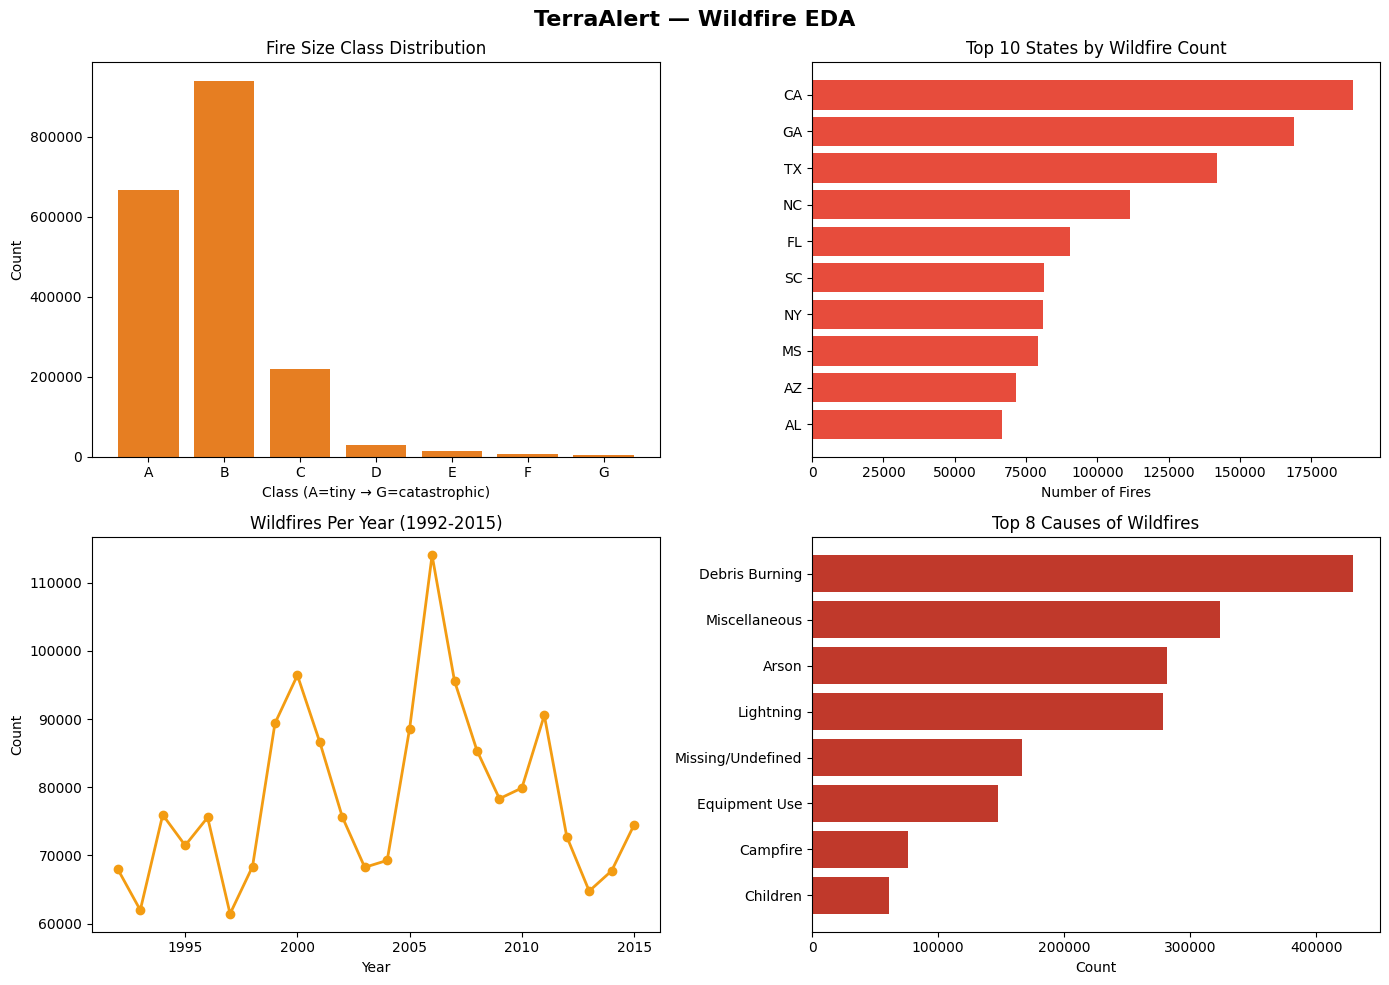

Plots saved ✅


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TerraAlert — Wildfire EDA', fontsize=16, fontweight='bold')

# Plot 1 - Fire class distribution
class_counts = df['FIRE_SIZE_CLASS'].value_counts().sort_index()
axes[0,0].bar(class_counts.index, class_counts.values, color='#e67e22')
axes[0,0].set_title('Fire Size Class Distribution')
axes[0,0].set_xlabel('Class (A=tiny → G=catastrophic)')
axes[0,0].set_ylabel('Count')

# Plot 2 - Top 10 states
top_states = df['STATE'].value_counts().head(10)
axes[0,1].barh(top_states.index[::-1], top_states.values[::-1], color='#e74c3c')
axes[0,1].set_title('Top 10 States by Wildfire Count')
axes[0,1].set_xlabel('Number of Fires')

# Plot 3 - Fires per year trend
yearly = df.groupby('FIRE_YEAR').size()
axes[1,0].plot(yearly.index, yearly.values, marker='o', color='#f39c12', linewidth=2)
axes[1,0].set_title('Wildfires Per Year (1992-2015)')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Count')

# Plot 4 - Top causes
causes = df['STAT_CAUSE_DESCR'].value_counts().head(8)
axes[1,1].barh(causes.index[::-1], causes.values[::-1], color='#c0392b')
axes[1,1].set_title('Top 8 Causes of Wildfires')
axes[1,1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../data/wildfires/eda_plots.png', dpi=150)
plt.show()
print('Plots saved ✅')

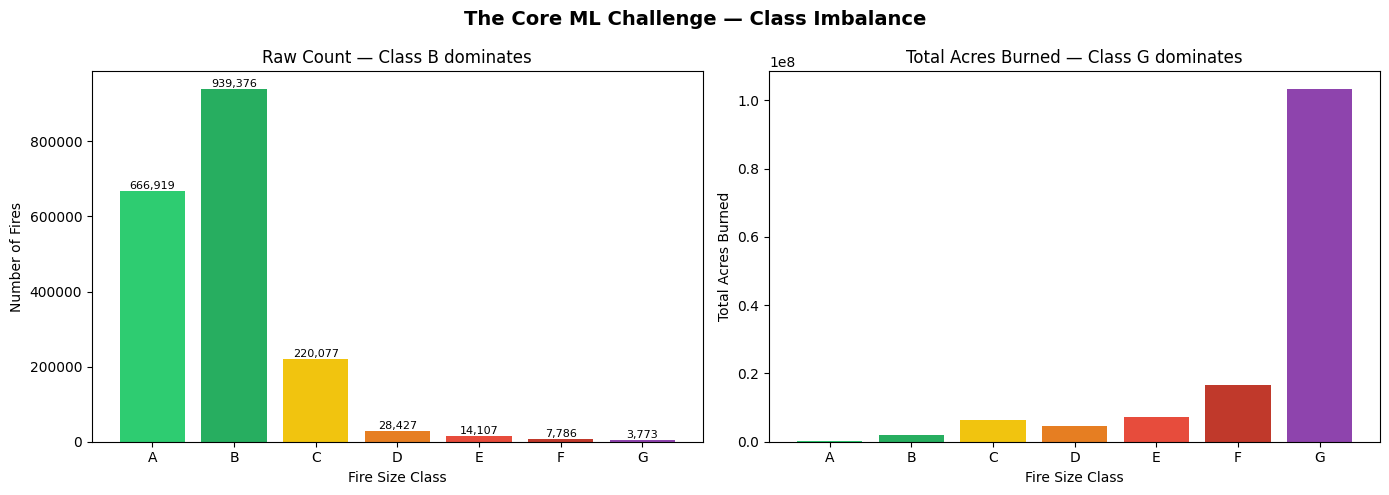

CLASS IMBALANCE SUMMARY:
Class B fires: 939,376 (50.0% of all fires)
Class G fires: 3,773 (0.2% of all fires)

Class G acres burned: 103,335,644
Class B acres burned: 2,016,839

Key insight: Class G is rare but burns 51x more acres than Class B


In [8]:
# Class imbalance visualization - the core ML challenge
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Core ML Challenge — Class Imbalance', fontsize=14, fontweight='bold')

# Plot 1 - Raw counts (shows imbalance)
class_counts = df['FIRE_SIZE_CLASS'].value_counts().sort_index()
colors = ['#2ecc71','#27ae60','#f1c40f','#e67e22','#e74c3c','#c0392b','#8e44ad']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Raw Count — Class B dominates')
axes[0].set_xlabel('Fire Size Class')
axes[0].set_ylabel('Number of Fires')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=8)

# Plot 2 - Total acres burned per class (catastrophic impact of G)
df['FIRE_SIZE'] = pd.to_numeric(df['FIRE_SIZE'], errors='coerce')
acres_by_class = df.groupby('FIRE_SIZE_CLASS')['FIRE_SIZE'].sum().sort_index()
bars2 = axes[1].bar(acres_by_class.index, acres_by_class.values, color=colors)
axes[1].set_title('Total Acres Burned — Class G dominates')
axes[1].set_xlabel('Fire Size Class')
axes[1].set_ylabel('Total Acres Burned')

plt.tight_layout()
plt.savefig('../data/wildfires/class_imbalance.png', dpi=150)
plt.show()

# Print the insight
print("CLASS IMBALANCE SUMMARY:")
print(f"Class B fires: {class_counts.get('B',0):,} ({class_counts.get('B',0)/len(df)*100:.1f}% of all fires)")
print(f"Class G fires: {class_counts.get('G',0):,} ({class_counts.get('G',0)/len(df)*100:.1f}% of all fires)")
print(f"\nClass G acres burned: {acres_by_class.get('G',0):,.0f}")
print(f"Class B acres burned: {acres_by_class.get('B',0):,.0f}")
print(f"\nKey insight: Class G is rare but burns {acres_by_class.get('G',0)/acres_by_class.get('B',0):.0f}x more acres than Class B")

In [9]:
# Save clean model-ready wildfire dataset
useful_cols = [
    'FIRE_YEAR', 'DISCOVERY_DOY', 'STAT_CAUSE_CODE',
    'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'STATE',
    'LATITUDE', 'LONGITUDE'
]

df_model = df[useful_cols].dropna()

# Encode state as number
df_model = df_model.copy()
df_model['STATE_CODE'] = pd.Categorical(df_model['STATE']).codes

print(f'Model-ready shape: {df_model.shape}')
print(f'Target distribution:')
print(df_model['FIRE_SIZE_CLASS'].value_counts())

df_model.to_csv('../data/wildfires/wildfires_processed.csv', index=False)
print('\nSaved wildfires_processed.csv ✅')
print('\nCheckpoint Summary:')
print(f'  Total fires: {len(df_model):,}')
print(f'  Features: {len(useful_cols)}')
print(f'  Next: Train RF vs XGBoost vs LightGBM')

Model-ready shape: (1880465, 9)
Target distribution:
FIRE_SIZE_CLASS
B    939376
A    666919
C    220077
D     28427
E     14107
F      7786
G      3773
Name: count, dtype: int64

Saved wildfires_processed.csv ✅

Checkpoint Summary:
  Total fires: 1,880,465
  Features: 8
  Next: Train RF vs XGBoost vs LightGBM


In [11]:
# Load NASA FIRMS live data
firms = pd.read_csv('../data/wildfires/nasa_firms_hotspots.csv')
print(f'NASA FIRMS (live satellite): {len(firms):,} hotspots')
print(f'Columns: {list(firms.columns)}')
print(f'\nKaggle historical: {len(df):,} records')

print(f'\nKey difference:')
print(f'  Kaggle = labeled historical fires (for training)')
print(f'  NASA FIRMS = live satellite detections (for inference)')
firms.head()

NASA FIRMS (live satellite): 1,145 hotspots
Columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight']

Kaggle historical: 1,880,465 records

Key difference:
  Kaggle = labeled historical fires (for training)
  NASA FIRMS = live satellite detections (for inference)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,30.50384,-88.88825,303.87,1.72,1.29,2026-03-29,211,Terra,MODIS,57,6.1NRT,286.85,15.92,N
1,31.85736,-84.93594,300.03,1.04,1.02,2026-03-29,211,Terra,MODIS,11,6.1NRT,286.86,5.50,N
2,31.94944,-88.76036,309.05,1.58,1.24,2026-03-29,211,Terra,MODIS,76,6.1NRT,282.75,22.72,N
3,33.29719,-84.89234,302.41,1.02,1.01,2026-03-29,211,Terra,MODIS,49,6.1NRT,284.90,7.46,N
4,33.40157,-89.84420,308.96,1.72,1.29,2026-03-29,211,Terra,MODIS,76,6.1NRT,280.92,27.88,N
